<a href="https://colab.research.google.com/github/gracyntaxx/SmartSales/blob/main/AML_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/sample_data/Cleaned_amazon_smartphones.csv")

print("Shape:", df.shape)
print(df.info())

Shape: (75, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           75 non-null     object 
 1   product_name         75 non-null     object 
 2   category             75 non-null     object 
 3   discounted_price     75 non-null     int64  
 4   actual_price         75 non-null     int64  
 5   discount_percentage  75 non-null     int64  
 6   rating               75 non-null     float64
 7   rating_count         75 non-null     int64  
 8   about_product        75 non-null     object 
 9   user_id              75 non-null     object 
 10  user_name            75 non-null     object 
 11  review_id            75 non-null     object 
 12  review_title         75 non-null     object 
 13  review_content       75 non-null     object 
 14  img_link             75 non-null     object 
 15  product_link         75 no

In [ ]:
print("Basic statistics:")       #This gives count, average,standard deviation, minimum, and maximum.
print(df.describe())             #values for price, discount, rating, and rating‑count.

Basic statistics:
       discounted_price  actual_price  discount_percentage     rating  \
count         75.000000     75.000000            75.000000  75.000000   
mean       14405.346667  18819.413333            22.800000   4.034667   
std         8732.205866  11656.290900             8.485281   0.489482   
min         1055.000000   1249.000000             0.000000   0.000000   
25%         8749.000000  11999.000000            19.000000   4.000000   
50%        13999.000000  18999.000000            24.000000   4.100000   
75%        16999.000000  21494.500000            28.000000   4.150000   
max        44999.000000  74999.000000            49.000000   4.400000   

        rating_count  
count      75.000000  
mean    40368.280000  
std     71126.032955  
min       125.000000  
25%      9438.500000  
50%     18998.000000  
75%     31364.500000  
max    313836.000000  


###Graph 1: Discounted Price vs Rating

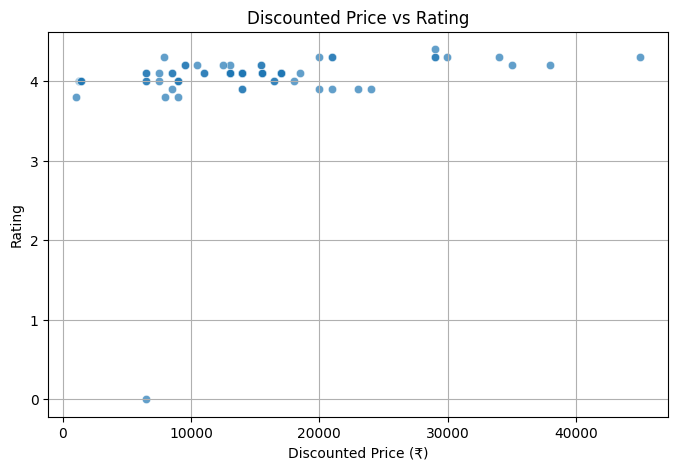

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="discounted_price", y="rating", data=df, alpha=0.7)
plt.title("Discounted Price vs Rating")
plt.xlabel("Discounted Price (₹)")
plt.ylabel("Rating")
plt.grid(True)
plt.show()

###Graph 2: Discount vs Demand (rating_count)

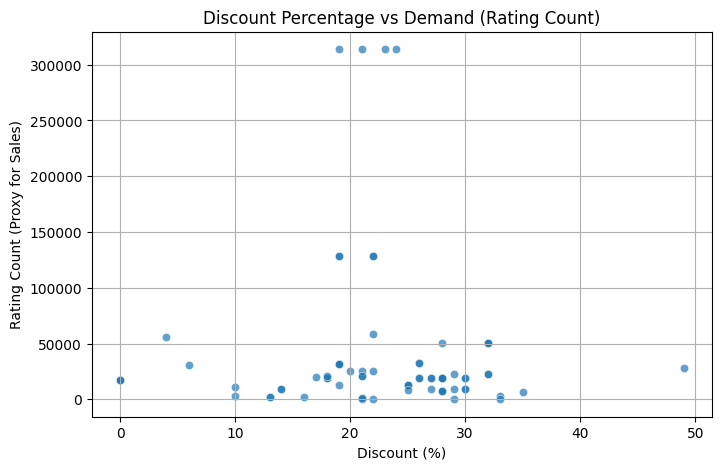

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="discount_percentage", y="rating_count", data=df, alpha=0.7)
plt.title("Discount Percentage vs Demand (Rating Count)")
plt.xlabel("Discount (%)")
plt.ylabel("Rating Count (Proxy for Sales)")
plt.grid(True)
plt.show()

###Graph 3: Distribution of Ratings

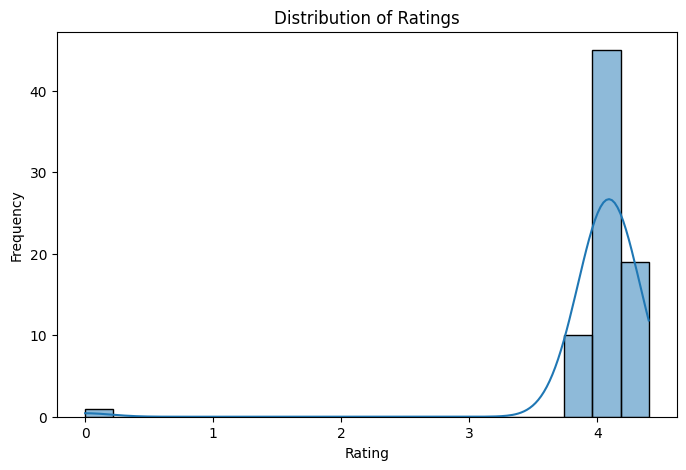

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["rating"], bins=20, kde=True)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

###Graph 4: Top‑Selling Phones (by rating_count)

/tmp/ipykernel_4963/3396343644.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x="rating_count",y="product_name", palette="Blues_r")


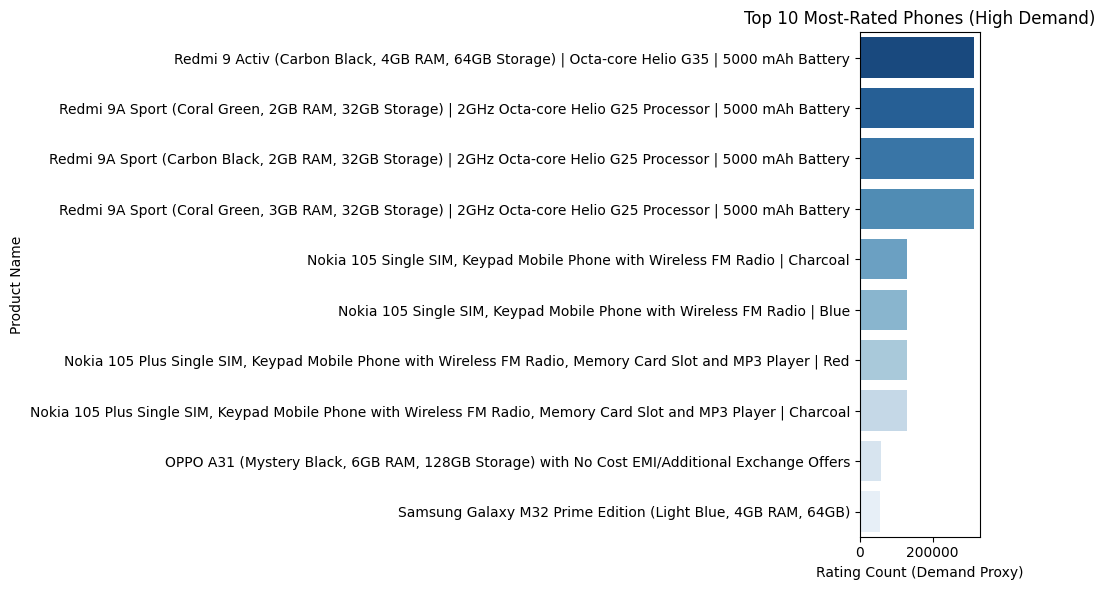

In [ ]:
top_10 = df.nlargest(10, "rating_count")

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x="rating_count",y="product_name", palette="Blues_r")
plt.title("Top 10 Most‑Rated Phones (High Demand)")
plt.xlabel("Rating Count (Demand Proxy)")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

###Graph 5: Price distribution (full vs discounted)

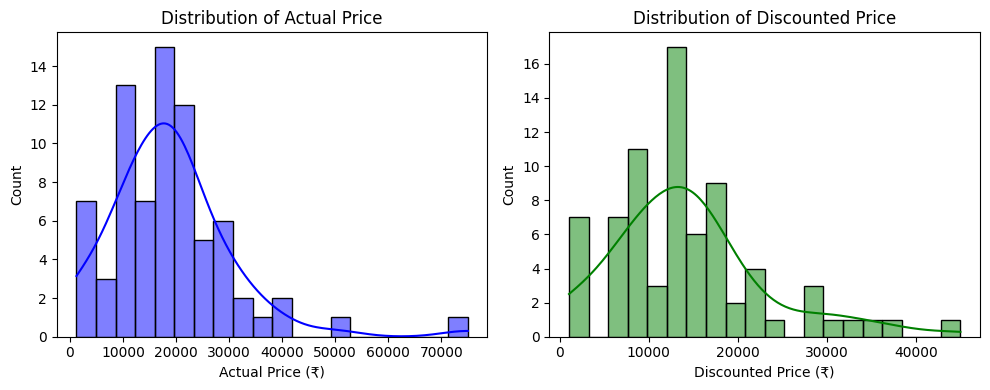

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df["actual_price"], bins=20, kde=True, color="blue")
plt.title("Distribution of Actual Price")
plt.xlabel("Actual Price (₹)")

plt.subplot(1, 2, 2)
sns.histplot(df["discounted_price"], bins=20, kde=True, color="green")
plt.title("Distribution of Discounted Price")
plt.xlabel("Discounted Price (₹)")

plt.tight_layout()
plt.show()

###Corelation Heatmap

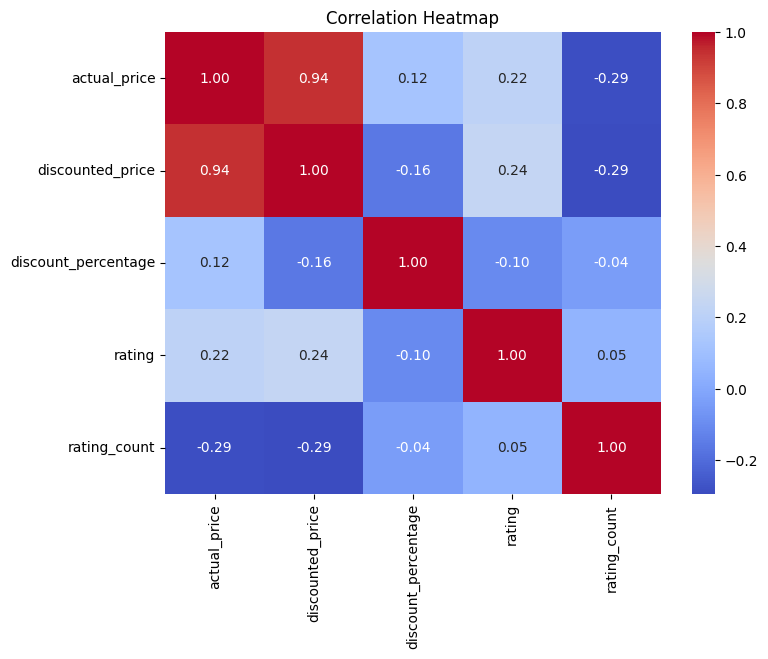

In [ ]:
plt.figure(figsize=(8, 6))
numeric_cols = ["actual_price", "discounted_price", "discount_percentage", "rating", "rating_count"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()